# KMeans, Kmeans++

**KMeans** — это один из самых популярных алгоритмов кластеризации, который разбивает данные на k кластеров на основе расстояния до центров (центроидов).

**Алгоритм работы**

1. Случайным образом выбираются k начальных центров кластеров
2. Каждая точка относится к ближайшему центру (по расстоянию, обычно евклидову)
3. Для каждого кластера пересчитывается центр как среднее всех точек
4. Шаги 2–3 повторяются до сходимости (центры перестают меняться)

Алгоритм минимизирует сумму квадратов расстояний до центров кластеров:

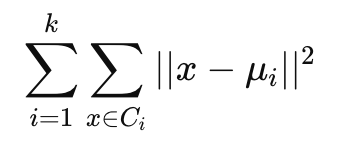

где:
Ci — кластер
μi — центр кластера
x — точка

**Kmeans++** — это улучшенная версия K-Means, которая решает проблему плохого выбора начальных центров.

Основная идея в том, чтобы выбирать начальные центры не случайно, а так, чтобы они были максимально удалены друг от друга.

# Используемые библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import mode

# Описание и демонстрация датасета

**Iris dataset** — это классический датасет для задач классификации и кластеризации, широко используемый в машинном обучении.

Датасет содержит измерения цветов ириса трёх различных видов:

* Iris setosa
* Iris versicolor
* Iris virginica

In [2]:
data = load_iris()

X = data.data
y = data.target

feature_names = data.feature_names
target_names = data.target_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [4]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


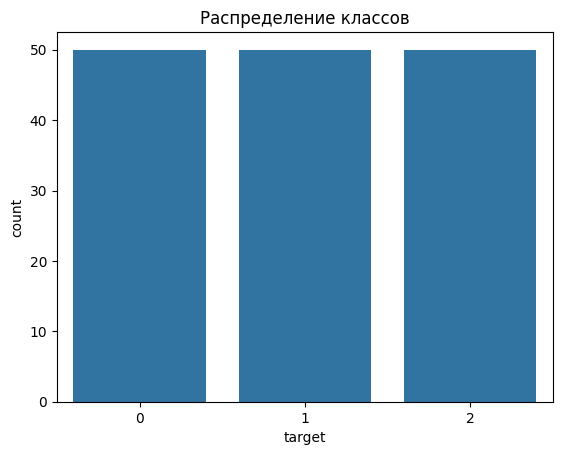

In [5]:
sns.countplot(x='target', data=df)
plt.title('Распределение классов')
plt.show()

# Препроцессинг датасета

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Обучение модели

**Метод локтя** — это способ определения оптимального количества кластеров (k) в алгоритме K-Means.

**Основная идея**

При увеличении числа кластеров:

* модель лучше подстраивается под данные
* расстояние точек до центров уменьшается

Но после некоторого момента улучшение становится незначительным. Этот «перелом» на графике и называется локтем

In [7]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

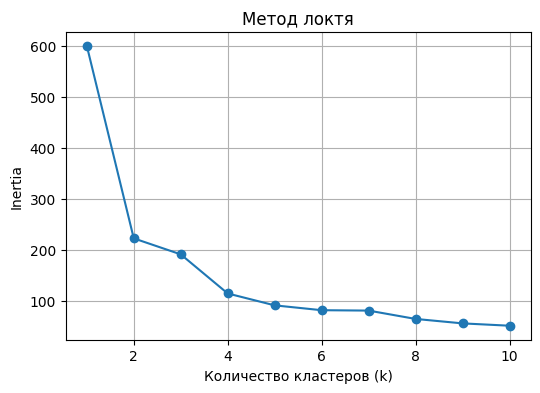

In [8]:
plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Inertia')
plt.title('Метод локтя')
plt.grid()
plt.show()

In [9]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
y_kmeans = kmeans.fit_predict(X)

# Оценка качества

In [10]:
score = silhouette_score(X_scaled, y_kmeans)
print("Silhouette Score:", score)

Silhouette Score: 0.44366157397640527


# Визуализация результатов

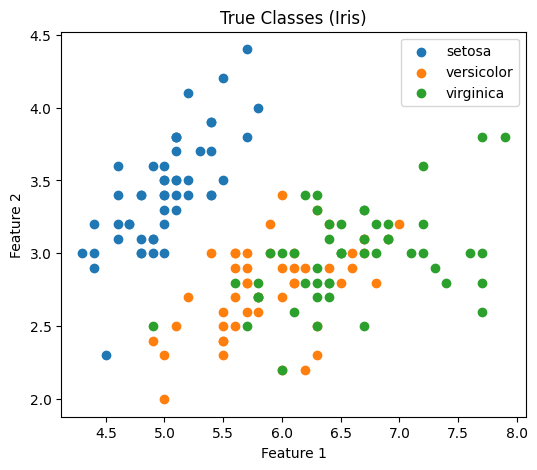

In [11]:
plt.figure(figsize=(6,5))

for cls in np.unique(y):
    plt.scatter(
        X[y == cls, 0],
        X[y == cls, 1],
        label=data.target_names[cls]
    )

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("True Classes (Iris)")
plt.legend()
plt.show()

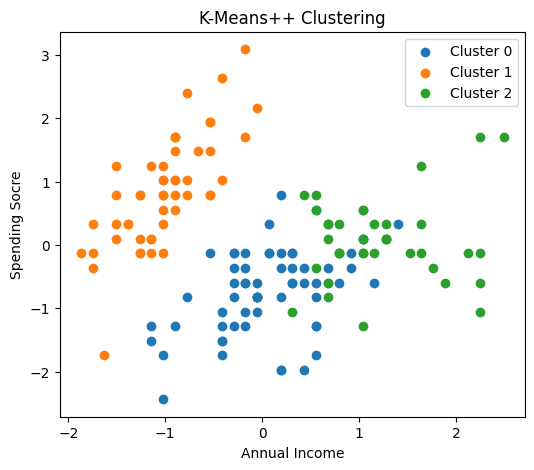

In [12]:
plt.figure(figsize=(6,5))

for cluster in np.unique(y_kmeans):
    plt.scatter(
        X_scaled[y_kmeans == cluster, 0],
        X_scaled[y_kmeans == cluster, 1],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Annual Income")
plt.ylabel("Spending Socre")
plt.title("K-Means++ Clustering")
plt.legend()
plt.show()

In [13]:
# создаём массив для новых "приведённых" меток
y_kmeans_mapped = np.zeros_like(y_kmeans)

for i in range(3):
    mask = (y_kmeans == i)
    y_kmeans_mapped[mask] = mode(y[mask], keepdims=True)[0]

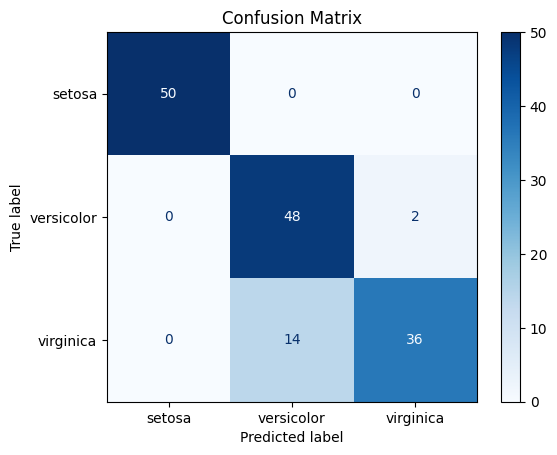

In [14]:
cm = confusion_matrix(y, y_kmeans_mapped)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=target_names)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()